In [1]:
# ============================================================
# Cell 1: Imports and Configuration
# ============================================================

import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ------------------------------------------------------------
# Path to the PREPROCESSED TEST DATASET
# ------------------------------------------------------------

TEST_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test"

# Folder containing test MRI images
TEST_IMAGE_DIR = os.path.join(TEST_PATH, "images")

# Folder containing corresponding ground-truth masks
TEST_MASK_DIR = os.path.join(TEST_PATH, "masks")

# ------------------------------------------------------------
# Path to the already-trained U-Net
# ------------------------------------------------------------

MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

# ------------------------------------------------------------
# Same image size used during training
# ------------------------------------------------------------

IMG_HEIGHT = 256
IMG_WIDTH = 256

# ------------------------------------------------------------
# Prediction threshold
# U-Net gives probabilities between 0 and 1.
# > 0.5 is considered tumor.
# ------------------------------------------------------------

THRESHOLD = 0.5

print("Test Image Folder :", TEST_IMAGE_DIR)
print("Test Mask Folder  :", TEST_MASK_DIR)
print("Model Path        :", MODEL_PATH)

Test Image Folder : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\images
Test Mask Folder  : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\masks
Model Path        : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras


# Load saved Unet

In [2]:
# ============================================================
# Cell 2: Define Custom Loss and Metrics
# ============================================================

# ------------------------------------------------------------
# Dice Coefficient
# ------------------------------------------------------------

def dice_coefficient(y_true, y_pred, smooth=1e-6):

    # Flatten the ground-truth mask
    y_true = tf.keras.backend.flatten(y_true)

    # Flatten the predicted mask
    y_pred = tf.keras.backend.flatten(y_pred)

    # Calculate intersection
    intersection = tf.reduce_sum(y_true * y_pred)

    # Calculate Dice score
    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


# ------------------------------------------------------------
# Dice Loss
# ------------------------------------------------------------

def dice_loss(y_true, y_pred):

    # Dice Loss = 1 - Dice
    return 1.0 - dice_coefficient(y_true, y_pred)


# ------------------------------------------------------------
# Binary Cross Entropy
# ------------------------------------------------------------

bce = tf.keras.losses.BinaryCrossentropy()


# ------------------------------------------------------------
# Total Loss used during your training
# BCE + Dice Loss
# ------------------------------------------------------------

def total_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


# ------------------------------------------------------------
# IoU Score
# ------------------------------------------------------------

def iou_score(y_true, y_pred, smooth=1e-6):

    # Flatten ground truth
    y_true = tf.keras.backend.flatten(y_true)

    # Flatten prediction
    y_pred = tf.keras.backend.flatten(y_pred)

    # Convert prediction into binary mask
    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    # Calculate intersection
    intersection = tf.reduce_sum(y_true * y_pred)

    # Calculate union
    union = (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) -
        intersection
    )

    # Return IoU
    return (
        intersection + smooth
    ) / (
        union + smooth
    )


# ============================================================
# Load the SAVED model
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "dice_loss": dice_loss,
        "iou_score": iou_score
    }
)

print("U-Net loaded successfully.")

U-Net loaded successfully.


# Check test data

In [3]:
# ============================================================
# Cell 3: Verify Test Dataset
# ============================================================

# Get all test image files
test_images = sorted([
    file
    for file in os.listdir(TEST_IMAGE_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    )
])

# Get all test mask files
test_masks = sorted([
    file
    for file in os.listdir(TEST_MASK_DIR)
    if file.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    )
])

# Display number of files
print("Number of Test Images :", len(test_images))
print("Number of Test Masks  :", len(test_masks))

# Make sure both counts are equal
assert len(test_images) == len(test_masks), \
    "Number of test images and masks do not match!"

print("\nTest dataset verified successfully.")

Number of Test Images : 860
Number of Test Masks  : 860

Test dataset verified successfully.


# Run predictioni on test data

In [10]:
# ============================================================
# Cell 4: FAST Batch Prediction with tqdm
# ============================================================

from tqdm.auto import tqdm

# Batch size
BATCH_SIZE = 16

# Lists to store results
all_true = []
all_pred = []
all_prob = []

# Temporary batches
image_batch = []
mask_batch = []

# ------------------------------------------------------------
# Process test images with progress bar
# ------------------------------------------------------------

for image_file in tqdm(
    test_images,
    desc="Processing test images",
    unit="image"
):

    # Image path
    image_path = os.path.join(
        TEST_IMAGE_DIR,
        image_file
    )

    # Image name without extension
    image_name = os.path.splitext(image_file)[0]

    # Corresponding mask
    mask_path = os.path.join(
        TEST_MASK_DIR,
        image_name + ".png"
    )

    # If PNG doesn't exist, try same filename
    if not os.path.exists(mask_path):

        mask_path = os.path.join(
            TEST_MASK_DIR,
            image_file
        )

    # Skip if mask doesn't exist
    if not os.path.exists(mask_path):

        print("\nMask not found:", image_file)
        continue

    # --------------------------------------------------------
    # Read MRI
    # --------------------------------------------------------

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    # Normalize
    image = image.astype(
        np.float32
    ) / 255.0

    # Add channel dimension
    image = np.expand_dims(
        image,
        axis=-1
    )

    # --------------------------------------------------------
    # Read mask
    # --------------------------------------------------------

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Resize mask
    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    # Binary mask
    mask = (
        mask > 127
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Add to batch
    # --------------------------------------------------------

    image_batch.append(image)
    mask_batch.append(mask)

    # --------------------------------------------------------
    # Predict when batch is full
    # --------------------------------------------------------

    if len(image_batch) == BATCH_SIZE:

        # Convert batch to NumPy array
        image_batch_array = np.array(
            image_batch,
            dtype=np.float32
        )

        # Predict entire batch
        prediction_probability = model.predict(
            image_batch_array,
            verbose=0
        )

        # Store predictions
        for j in range(len(image_batch)):

            probability = prediction_probability[
                j, :, :, 0
            ]

            # Convert probability to binary mask
            prediction = (
                probability >= THRESHOLD
            ).astype(np.uint8)

            # Store flattened results
            all_true.append(
                mask_batch[j].flatten()
            )

            all_pred.append(
                prediction.flatten()
            )

            all_prob.append(
                probability.flatten()
            )

        # Clear batch
        image_batch = []
        mask_batch = []


# ------------------------------------------------------------
# Process remaining images
# ------------------------------------------------------------

if len(image_batch) > 0:

    # Convert remaining images to array
    image_batch_array = np.array(
        image_batch,
        dtype=np.float32
    )

    # Predict remaining batch
    prediction_probability = model.predict(
        image_batch_array,
        verbose=0
    )

    # Store remaining predictions
    for j in range(len(image_batch)):

        probability = prediction_probability[
            j, :, :, 0
        ]

        # Convert to binary mask
        prediction = (
            probability >= THRESHOLD
        ).astype(np.uint8)

        # Store results
        all_true.append(
            mask_batch[j].flatten()
        )

        all_pred.append(
            prediction.flatten()
        )

        all_prob.append(
            probability.flatten()
        )


# ------------------------------------------------------------
# Combine all results
# ------------------------------------------------------------

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)
all_prob = np.concatenate(all_prob)


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("Test dataset prediction completed")
print("=" * 50)

print(
    "Test images processed:",
    len(test_images)
)

print(
    "Total test pixels evaluated:",
    len(all_true)
)

Processing test images:   0%|          | 0/860 [00:00<?, ?image/s]


Test dataset prediction completed
Test images processed: 860
Total test pixels evaluated: 56360960


# calculate parameters

In [11]:
# ============================================================
# Cell 5: Calculate Segmentation Metrics
# ============================================================

# ------------------------------------------------------------
# Calculate confusion matrix components
# ------------------------------------------------------------

TP = np.sum(
    (all_true == 1) &
    (all_pred == 1)
)

TN = np.sum(
    (all_true == 0) &
    (all_pred == 0)
)

FP = np.sum(
    (all_true == 0) &
    (all_pred == 1)
)

FN = np.sum(
    (all_true == 1) &
    (all_pred == 0)
)


# ------------------------------------------------------------
# Dice Coefficient
# ------------------------------------------------------------

dice = (
    2 * TP
) / (
    2 * TP + FP + FN
)


# ------------------------------------------------------------
# IoU
# ------------------------------------------------------------

iou = TP / (
    TP + FP + FN
)


# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

precision = TP / (
    TP + FP
)


# ------------------------------------------------------------
# Recall / Sensitivity
# ------------------------------------------------------------

recall = TP / (
    TP + FN
)


# ------------------------------------------------------------
# Specificity
# ------------------------------------------------------------

specificity = TN / (
    TN + FP
)


# ------------------------------------------------------------
# F1 Score
# ------------------------------------------------------------

f1 = (
    2 * precision * recall
) / (
    precision + recall
)


# ------------------------------------------------------------
# Pixel Accuracy
# ------------------------------------------------------------

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN
)


# ============================================================
# Print Results
# ============================================================

print("=" * 55)
print("          U-NET TEST DATASET EVALUATION")
print("=" * 55)

print(f"Dice Coefficient : {dice:.4f}")
print(f"IoU Score        : {iou:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"Sensitivity      : {recall:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"Pixel Accuracy   : {accuracy:.4f}")

print("=" * 55)

print("\nConfusion Matrix Components")
print("----------------------------")
print("True Positive  :", TP)
print("True Negative  :", TN)
print("False Positive :", FP)
print("False Negative :", FN)

          U-NET TEST DATASET EVALUATION
Dice Coefficient : 0.8569
IoU Score        : 0.7496
Precision        : 0.8902
Recall           : 0.8260
Sensitivity      : 0.8260
Specificity      : 0.9978
F1 Score         : 0.8569
Pixel Accuracy   : 0.9942

Confusion Matrix Components
----------------------------
True Positive  : 984788
True Negative  : 55047174
False Positive : 121507
False Negative : 207491


# metrics table 

In [12]:
# ============================================================
# Cell 6: Metrics Table
# ============================================================

metrics_data = {
    "Metric": [
        "Dice Coefficient",
        "IoU",
        "Precision",
        "Recall",
        "Sensitivity",
        "Specificity",
        "F1 Score",
        "Pixel Accuracy"
    ],

    "Score": [
        dice,
        iou,
        precision,
        recall,
        recall,
        specificity,
        f1,
        accuracy
    ]
}


# Create Pandas DataFrame
metrics_df = pd.DataFrame(
    metrics_data
)


# Convert score to percentage
metrics_df["Percentage"] = (
    metrics_df["Score"] * 100
).round(2)


# Display table
display(metrics_df)

,Metric,Score,Percentage
0,Dice Coefficient,0.856869,85.69
1,IoU,0.749580,74.96
2,Precision,0.890168,89.02
3,Recall,0.825971,82.60
4,Sensitivity,0.825971,82.60
5,Specificity,0.997798,99.78
6,F1 Score,0.856869,85.69
7,Pixel Accuracy,0.994163,99.42


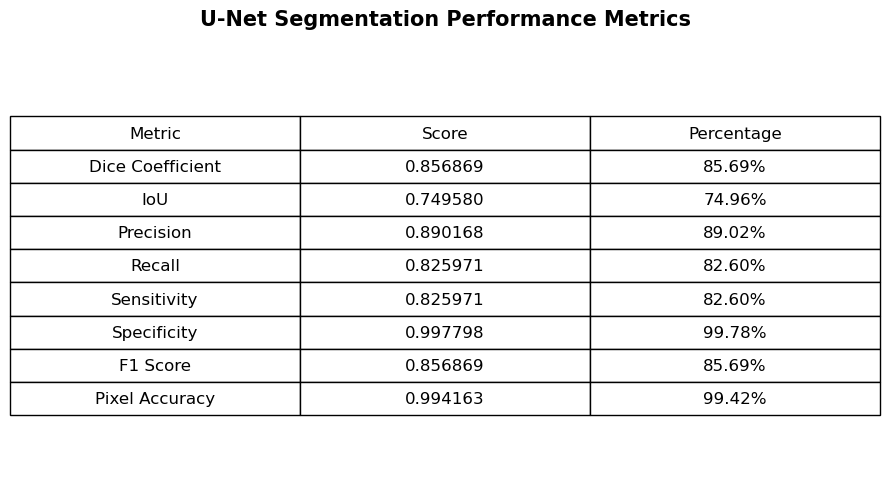

In [2]:
import matplotlib.pyplot as plt

# Data
metrics = [
    "Dice Coefficient",
    "IoU",
    "Precision",
    "Recall",
    "Sensitivity",
    "Specificity",
    "F1 Score",
    "Pixel Accuracy"
]

scores = [
    0.856869,
    0.749580,
    0.890168,
    0.825971,
    0.825971,
    0.997798,
    0.856869,
    0.994163
]

percentages = [
    85.69,
    74.96,
    89.02,
    82.60,
    82.60,
    99.78,
    85.69,
    99.42
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Hide axes
ax.axis("off")

# Create table
table_data = []

for metric, score, percentage in zip(metrics, scores, percentages):
    table_data.append([
        metric,
        f"{score:.6f}",
        f"{percentage:.2f}%"
    ])

table = ax.table(
    cellText=table_data,
    colLabels=["Metric", "Score", "Percentage"],
    loc="center",
    cellLoc="center",
    colLoc="center"
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

# Title
plt.title(
    "U-Net Segmentation Performance Metrics",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

# Plot metrics

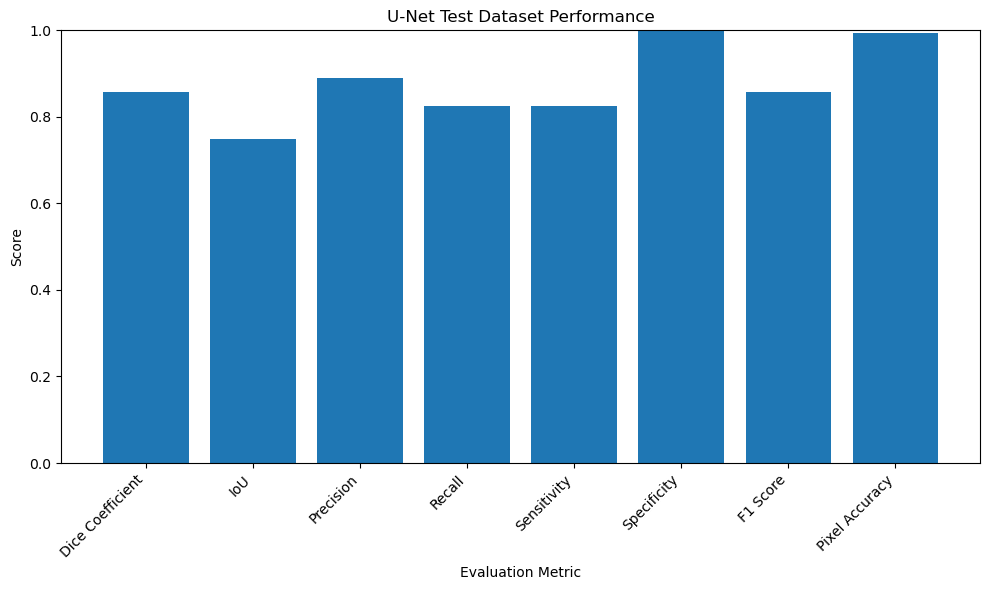

In [13]:
# ============================================================
# Cell 7: Metric Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.ylabel("Score")

plt.xlabel("Evaluation Metric")

plt.title(
    "U-Net Test Dataset Performance"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

# Pixel level confusion matrix

Pixel-Level Confusion Matrix
-----------------------------
[[55047174   121507]
 [  207491   984788]]


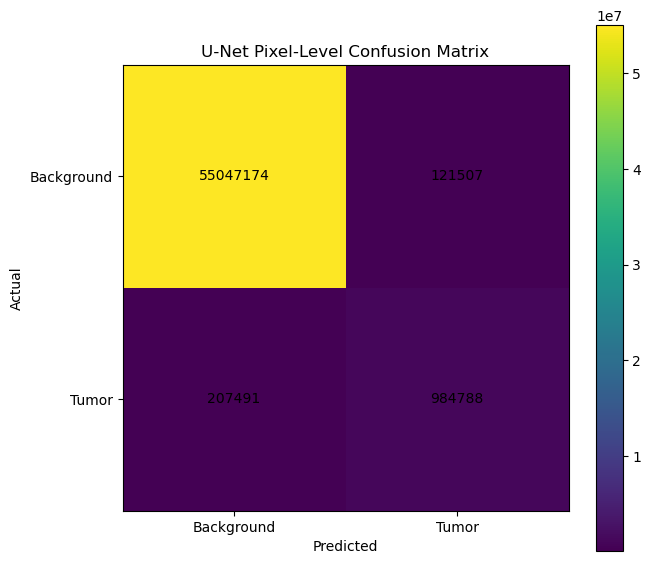

In [14]:
# ============================================================
# Cell 8: Pixel-Level Confusion Matrix
# ============================================================

# Create confusion matrix manually
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print("Pixel-Level Confusion Matrix")
print("-----------------------------")
print(confusion_matrix)


# ------------------------------------------------------------
# Visualize confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    confusion_matrix,
    interpolation="nearest"
)

plt.title(
    "U-Net Pixel-Level Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Background", "Tumor"]
)

plt.yticks(
    [0, 1],
    ["Background", "Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")


# Add numbers inside cells
for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()

# Random test Images

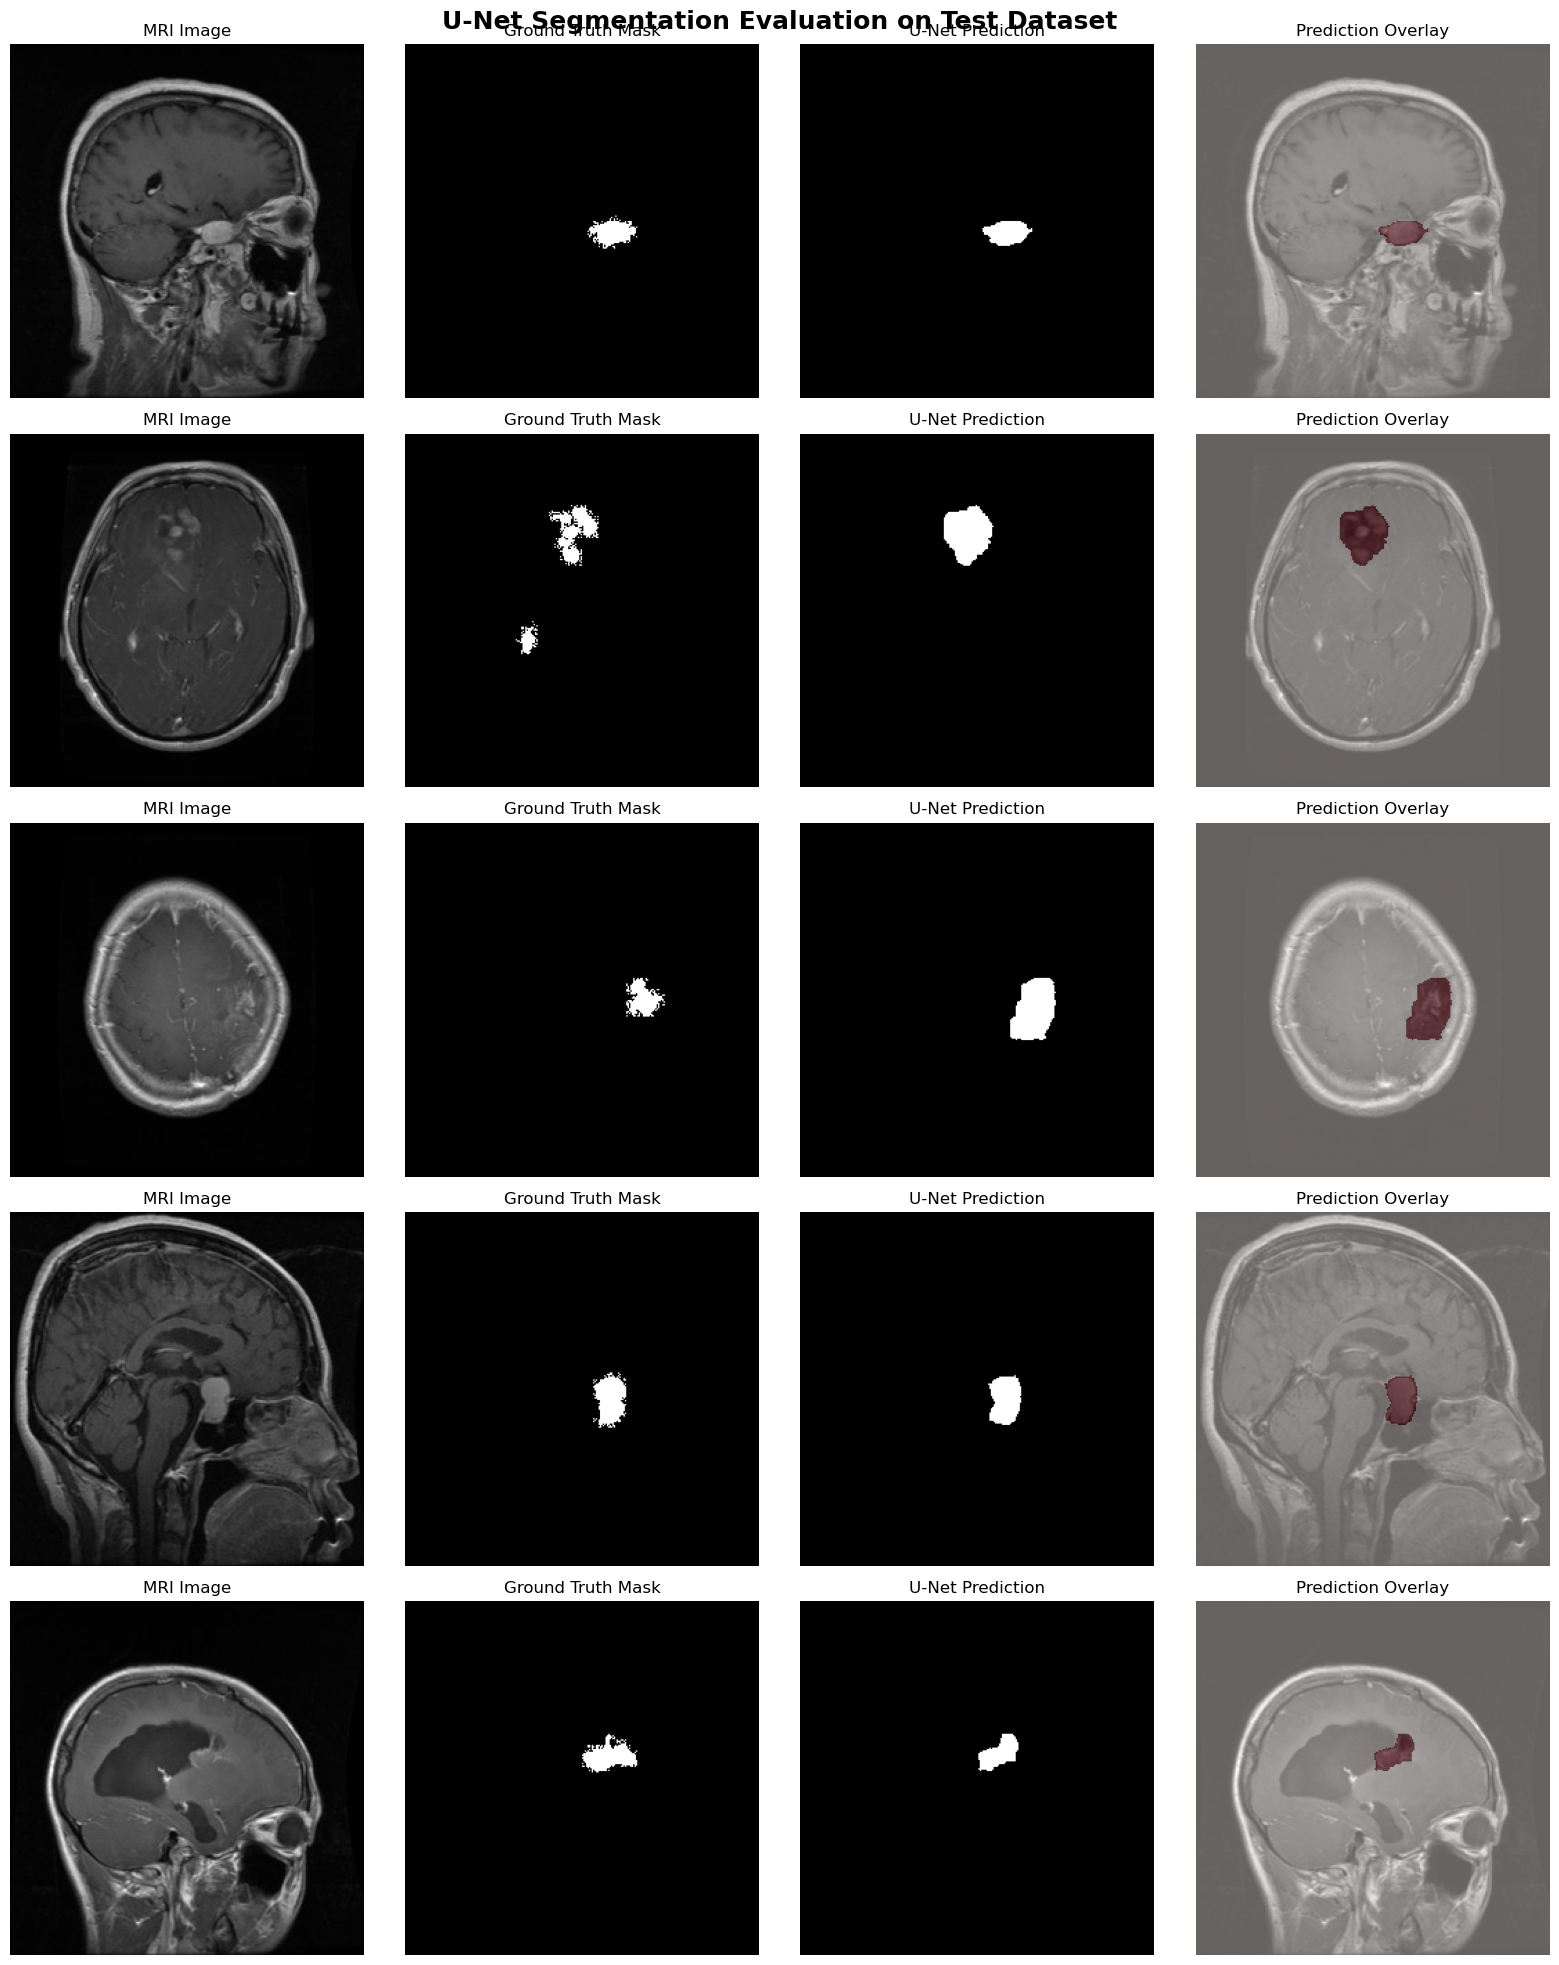

In [17]:
# ============================================================
# Cell 9: Random Test Sample Visualization
# ============================================================

# Number of random samples
NUM_SAMPLES = 5

# Randomly select test images
random_files = random.sample(
    test_images,
    min(NUM_SAMPLES, len(test_images))
)


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(random_files),
    4,
    figsize=(16, 4 * len(random_files))
)


# Handle one-image case
if len(random_files) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


# ------------------------------------------------------------
# Process every selected image
# ------------------------------------------------------------

for row, image_file in enumerate(random_files):

    # Image path
    image_path = os.path.join(
        TEST_IMAGE_DIR,
        image_file
    )

    # Image name
    image_name = os.path.splitext(
        image_file
    )[0]

    # Mask path
    mask_path = os.path.join(
        TEST_MASK_DIR,
        image_name + ".png"
    )

    # If PNG does not exist, use same filename
    if not os.path.exists(mask_path):

        mask_path = os.path.join(
            TEST_MASK_DIR,
            image_file
        )


    # --------------------------------------------------------
    # Load MRI
    # --------------------------------------------------------

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    image_norm = (
        image.astype(np.float32) / 255.0
    )


    # --------------------------------------------------------
    # Load ground truth
    # --------------------------------------------------------

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (
        mask > 127
    ).astype(np.float32)


    # --------------------------------------------------------
    # U-Net prediction
    # --------------------------------------------------------

    input_image = np.expand_dims(
        image_norm,
        axis=(0, -1)
    )

    prediction_probability = model.predict(
        input_image,
        verbose=0
    )[0, :, :, 0]


    # Convert probability to binary mask
    prediction = (
        prediction_probability >= THRESHOLD
    ).astype(np.float32)


    # --------------------------------------------------------
    # MRI
    # --------------------------------------------------------

    axes[row, 0].imshow(
        image_norm,
        cmap="gray"
    )

    axes[row, 0].set_title(
        "MRI Image"
    )

    axes[row, 0].axis("off")


    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------

    axes[row, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Ground Truth Mask"
    )

    axes[row, 1].axis("off")


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 2].set_title(
        "U-Net Prediction"
    )

    axes[row, 2].axis("off")


    # --------------------------------------------------------
    # Overlay
    # --------------------------------------------------------

    axes[row, 3].imshow(
        image_norm,
        cmap="gray"
    )

    axes[row, 3].imshow(
        prediction,
        cmap="Reds",
        alpha=0.4
    )

    axes[row, 3].set_title(
        "Prediction Overlay"
    )

    axes[row, 3].axis("off")


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

plt.suptitle(
    "U-Net Segmentation Evaluation on Test Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Ground Truth vs Prediction Overlay 

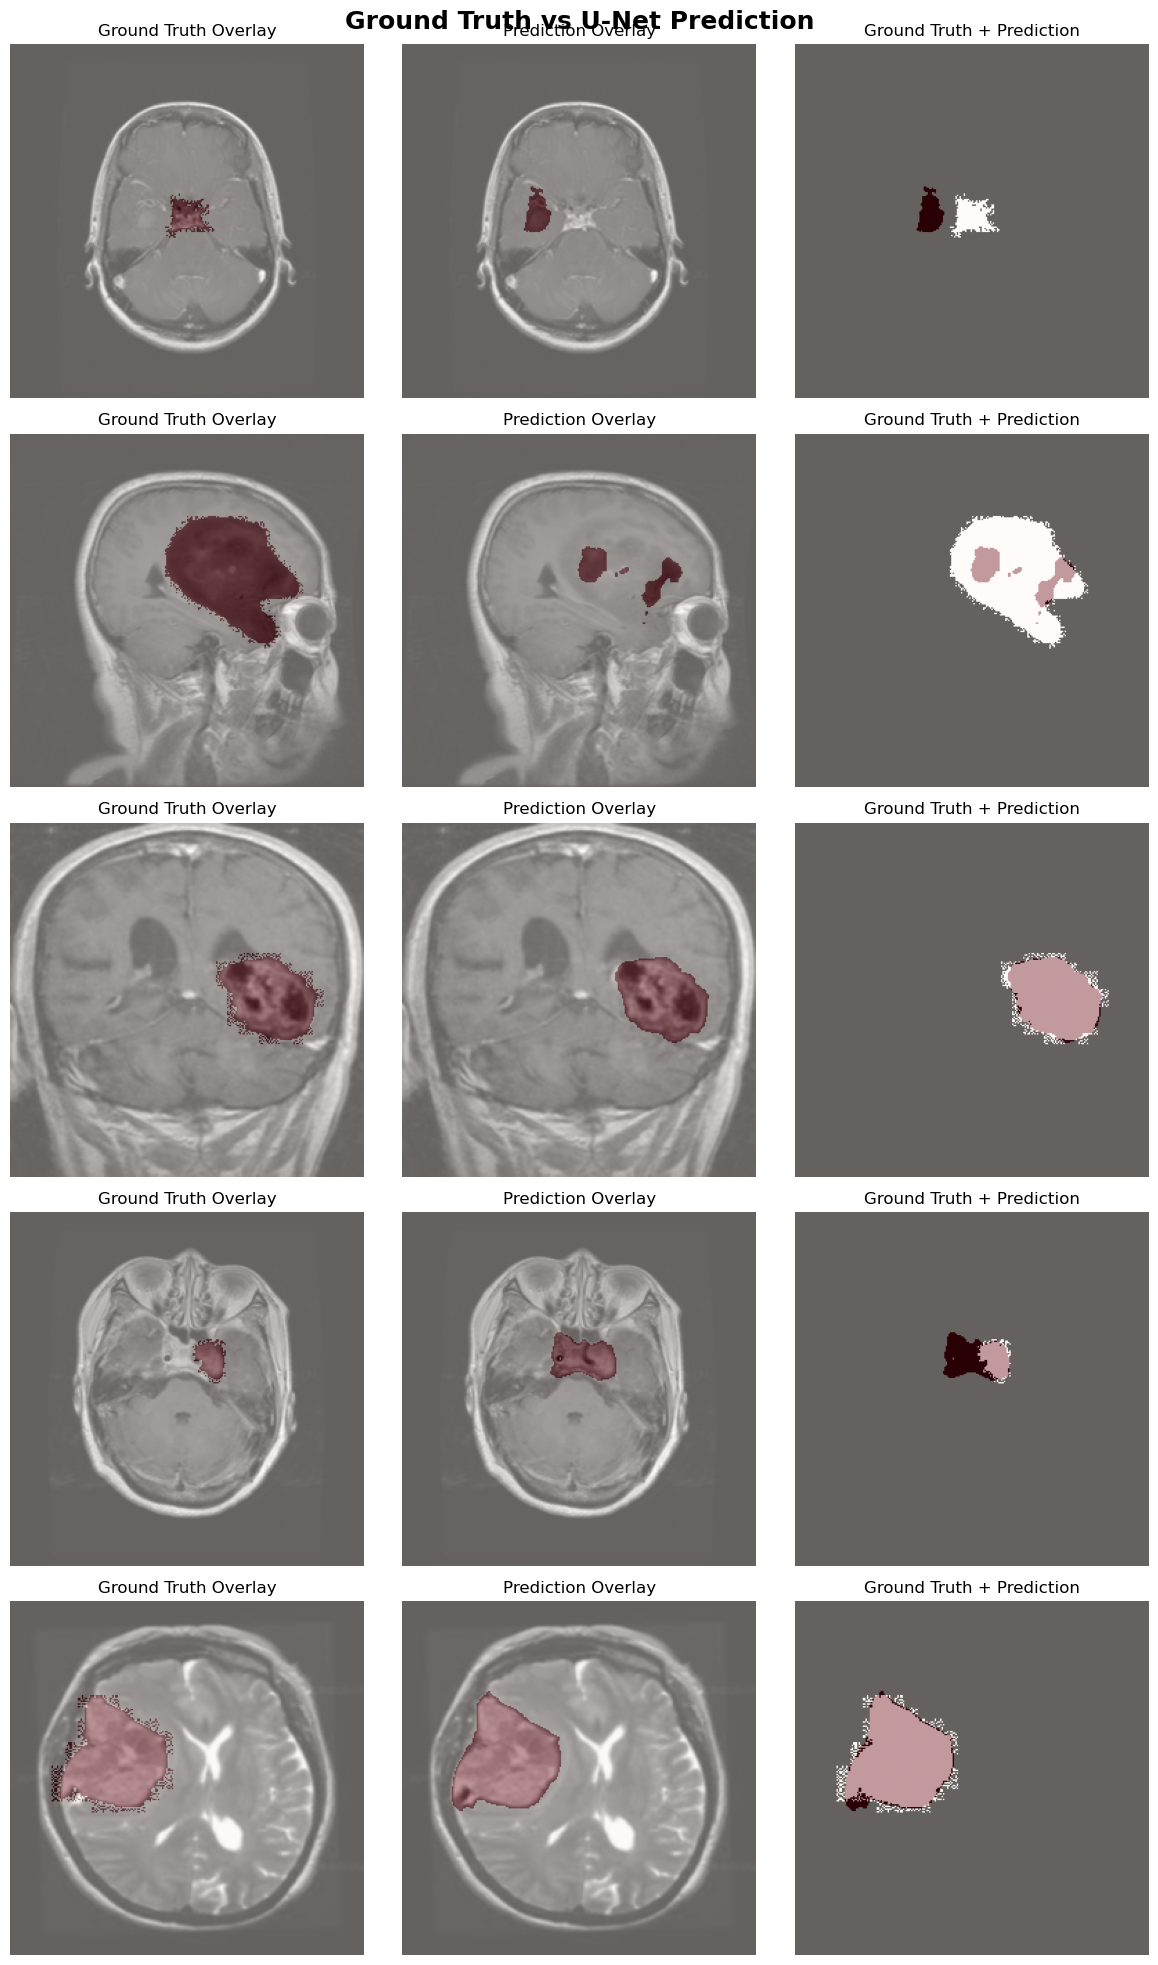

In [18]:
# ============================================================
# Cell 10: Ground Truth vs Prediction Comparison
# ============================================================

NUM_SAMPLES = 5

random_files = random.sample(
    test_images,
    min(NUM_SAMPLES, len(test_images))
)


fig, axes = plt.subplots(
    len(random_files),
    3,
    figsize=(12, 4 * len(random_files))
)


if len(random_files) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


for row, image_file in enumerate(random_files):

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    image_path = os.path.join(
        TEST_IMAGE_DIR,
        image_file
    )

    image_name = os.path.splitext(
        image_file
    )[0]

    mask_path = os.path.join(
        TEST_MASK_DIR,
        image_name + ".png"
    )

    if not os.path.exists(mask_path):

        mask_path = os.path.join(
            TEST_MASK_DIR,
            image_file
        )


    # --------------------------------------------------------
    # Load MRI
    # --------------------------------------------------------

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    image = (
        image.astype(np.float32) / 255.0
    )


    # --------------------------------------------------------
    # Load Ground Truth
    # --------------------------------------------------------

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    mask = (
        mask > 127
    ).astype(np.float32)


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    input_image = np.expand_dims(
        image,
        axis=(0, -1)
    )

    prediction = model.predict(
        input_image,
        verbose=0
    )[0, :, :, 0]


    prediction = (
        prediction >= THRESHOLD
    ).astype(np.float32)


    # --------------------------------------------------------
    # MRI + Ground Truth
    # --------------------------------------------------------

    axes[row, 0].imshow(
        image,
        cmap="gray"
    )

    axes[row, 0].imshow(
        mask,
        cmap="Reds",
        alpha=0.4
    )

    axes[row, 0].set_title(
        "Ground Truth Overlay"
    )

    axes[row, 0].axis("off")


    # --------------------------------------------------------
    # MRI + Prediction
    # --------------------------------------------------------

    axes[row, 1].imshow(
        image,
        cmap="gray"
    )

    axes[row, 1].imshow(
        prediction,
        cmap="Reds",
        alpha=0.4
    )

    axes[row, 1].set_title(
        "Prediction Overlay"
    )

    axes[row, 1].axis("off")


    # --------------------------------------------------------
    # Ground Truth vs Prediction
    # --------------------------------------------------------

    axes[row, 2].imshow(
        mask,
        cmap="gray"
    )

    axes[row, 2].imshow(
        prediction,
        cmap="Reds",
        alpha=0.4
    )

    axes[row, 2].set_title(
        "Ground Truth + Prediction"
    )

    axes[row, 2].axis("off")


plt.suptitle(
    "Ground Truth vs U-Net Prediction",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Classification image testing 

Loaded model from: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras


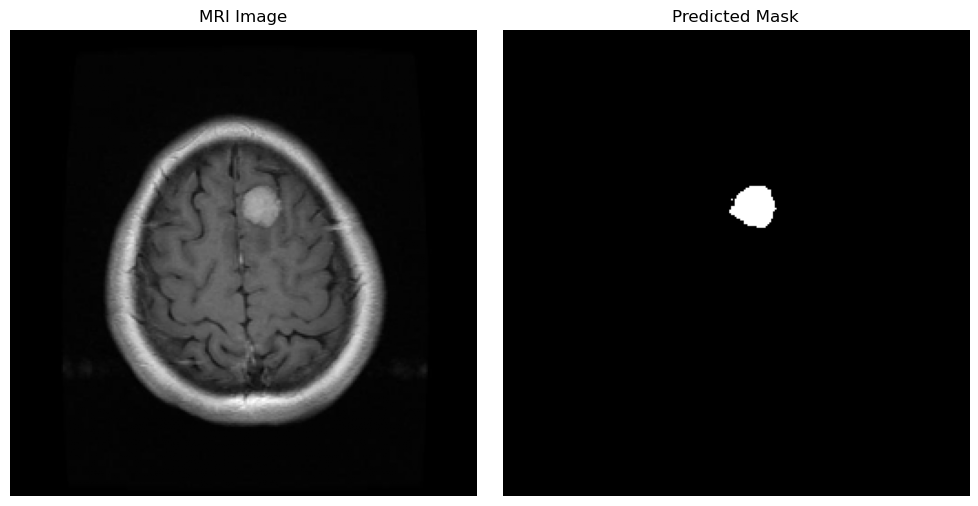

In [1]:
# ============================================================
# Predict & Visualize Mask for Any Single Image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---------------- Config ----------------
IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification\train\meningioma\brisc2025_train_01160_me_ax_t1.jpg"
MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

IMG_HEIGHT = 256
IMG_WIDTH = 256

# ---------------- Redefine custom loss/metric functions ----------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

# ---------------- Load model ----------------
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print(f"Loaded model from: {MODEL_PATH}")

# ---------------- Load & preprocess image ----------------
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError(f"Could not read image: {IMAGE_PATH}")

image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
image_norm = image.astype(np.float32) / 255.0
image_input = np.expand_dims(image_norm, axis=(0, -1))  # shape (1, H, W, 1)

# ---------------- Predict ----------------
pred = model.predict(image_input, verbose=0)
pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)

# ---------------- Plot ----------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_norm, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Loading U-Net model...
Model loaded successfully.

Model Input Shape : (None, 256, 256, 1)
Model Output Shape: (None, 256, 256, 1)

Number of layers: 76

Loading MRI image...
Original shape : (236, 236)
Resized shape  : (256, 256)
Model input    : (1, 256, 256, 1)

Running U-Net prediction...

Probability range: 9.558604e-07 to 0.9993235

SEGMENTATION RESULT
Tumor pixels     : 121
Total pixels     : 65536
Tumor area       : 0.18 %
Tumor detected   : YES
Threshold        : 0.5


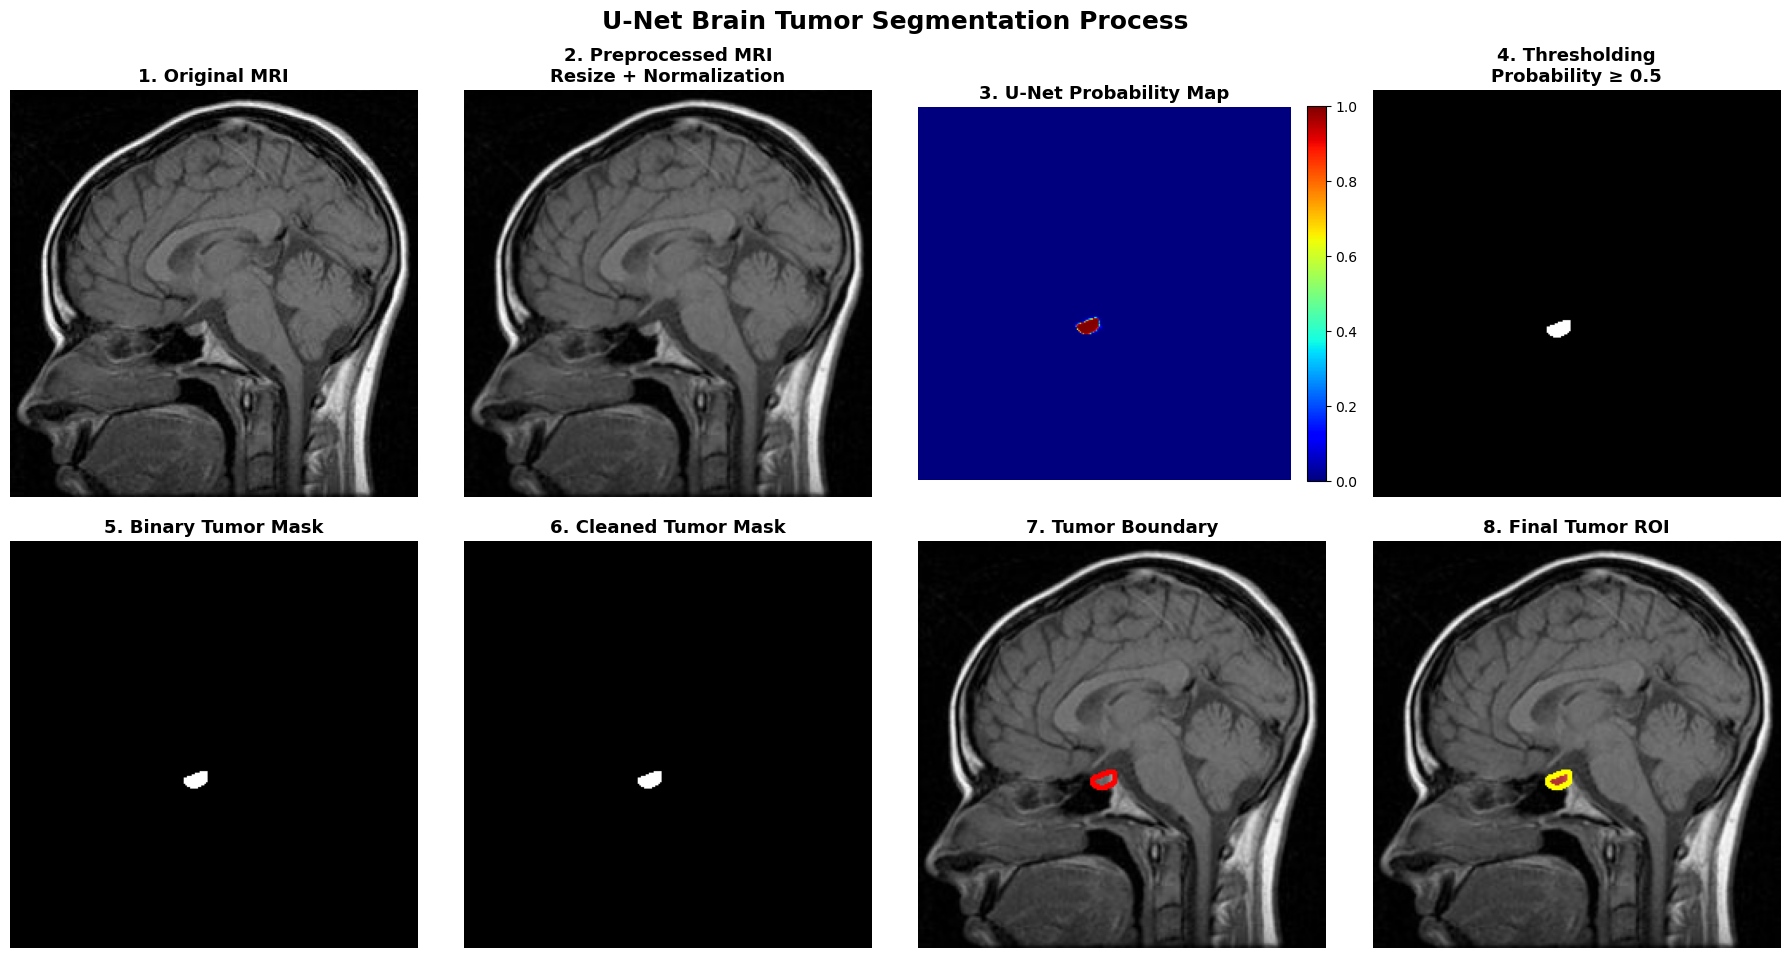

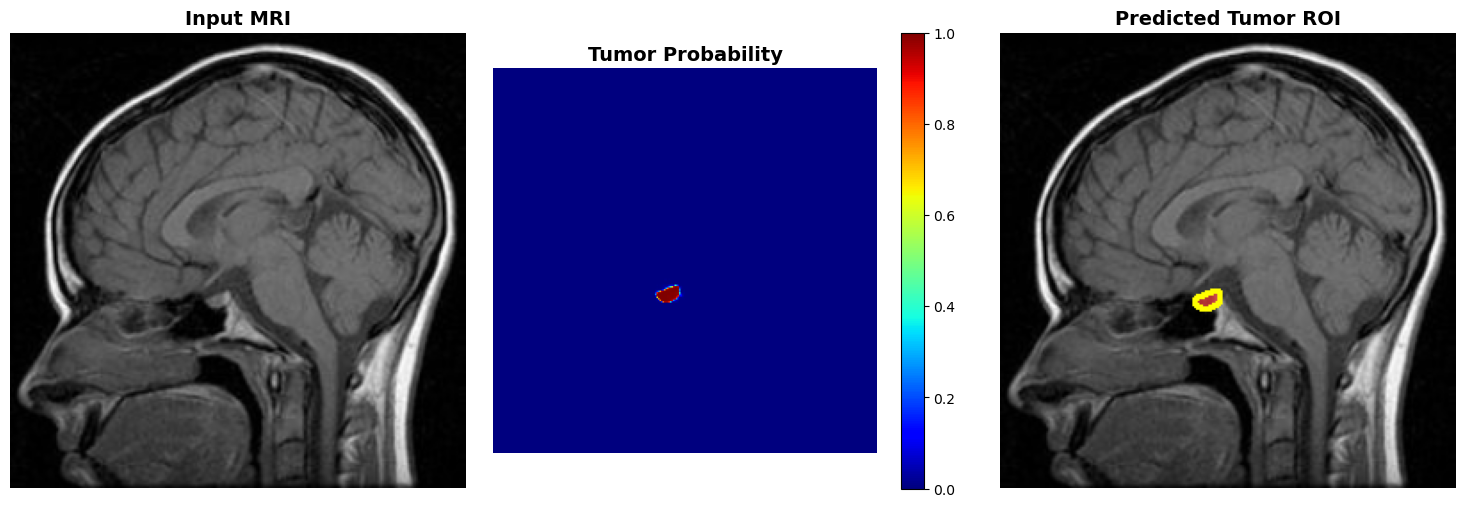

In [5]:
# ============================================================
# U-NET TUMOR SEGMENTATION — STEP-BY-STEP VISUALIZATION
# ============================================================
#
# Shows:
# 1. Original MRI
# 2. Preprocessed MRI
# 3. U-Net probability map
# 4. Thresholding process
# 5. Binary tumor mask
# 6. Tumor contour
# 7. Final tumor ROI overlay
#
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 1. CONFIGURATION
# ============================================================

IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\brisc2025\no_tumor\brisc2025_train_03467_no_sa_t1.jpg"

MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

IMG_HEIGHT = 256
IMG_WIDTH = 256

THRESHOLD = 0.5


# ============================================================
# 2. CUSTOM LOSS / METRIC FUNCTIONS
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        + smooth
    )


def dice_loss(y_true, y_pred):

    return 1.0 - dice_coefficient(y_true, y_pred)


bce = tf.keras.losses.BinaryCrossentropy()


def total_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    union = (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        - intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


# ============================================================
# 3. LOAD TRAINED U-NET MODEL
# ============================================================

print("Loading U-Net model...")

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print("Model loaded successfully.")
print()


# ============================================================
# 4. DISPLAY MODEL INFORMATION
# ============================================================

print("Model Input Shape :", model.input_shape)
print("Model Output Shape:", model.output_shape)
print()

print("Number of layers:", len(model.layers))


# ============================================================
# 5. LOAD MRI IMAGE
# ============================================================

print("\nLoading MRI image...")

image = cv2.imread(
    IMAGE_PATH,
    cv2.IMREAD_GRAYSCALE
)

if image is None:

    raise ValueError(
        f"Could not read image:\n{IMAGE_PATH}"
    )


original_image = image.copy()


# ============================================================
# 6. PREPROCESSING
# ============================================================

# Resize MRI
image_resized = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT)
)


# Normalize pixel values
image_norm = (
    image_resized.astype(np.float32)
    / 255.0
)


# Prepare image for U-Net
image_input = np.expand_dims(
    image_norm,
    axis=(0, -1)
)


print("Original shape :", original_image.shape)
print("Resized shape  :", image_resized.shape)
print("Model input    :", image_input.shape)


# ============================================================
# 7. U-NET PREDICTION
# ============================================================

print("\nRunning U-Net prediction...")

prediction = model.predict(
    image_input,
    verbose=0
)


# ============================================================
# 8. EXTRACT PROBABILITY MAP
# ============================================================

probability_map = prediction[
    0, :, :, 0
]


print(
    "\nProbability range:",
    probability_map.min(),
    "to",
    probability_map.max()
)


# ============================================================
# 9. THRESHOLDING
# ============================================================

binary_mask = (
    probability_map >= THRESHOLD
).astype(np.uint8)


# ============================================================
# 10. CLEAN THE MASK
# ============================================================

# Convert to 0–255
mask_uint8 = (
    binary_mask * 255
).astype(np.uint8)


# Morphological operations
kernel = np.ones(
    (3, 3),
    np.uint8
)


# Remove small noise
clean_mask = cv2.morphologyEx(
    mask_uint8,
    cv2.MORPH_OPEN,
    kernel
)


# Fill small holes
clean_mask = cv2.morphologyEx(
    clean_mask,
    cv2.MORPH_CLOSE,
    kernel
)


# Convert back to binary
clean_binary_mask = (
    clean_mask > 0
).astype(np.uint8)


# ============================================================
# 11. FIND TUMOR CONTOURS
# ============================================================

contours, _ = cv2.findContours(
    clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# ============================================================
# 12. CREATE CONTOUR IMAGE
# ============================================================

contour_image = cv2.cvtColor(
    image_resized,
    cv2.COLOR_GRAY2RGB
)


cv2.drawContours(
    contour_image,
    contours,
    -1,
    (255, 0, 0),
    2
)


# ============================================================
# 13. CREATE ROI OVERLAY
# ============================================================

overlay = cv2.cvtColor(
    image_resized,
    cv2.COLOR_GRAY2RGB
)


# Create colored tumor region
tumor_region = np.zeros_like(
    overlay
)

tumor_region[:, :, 0] = 255


# Blend only where tumor exists
mask_bool = clean_binary_mask.astype(bool)


overlay[mask_bool] = cv2.addWeighted(
    overlay[mask_bool],
    0.5,
    tumor_region[mask_bool],
    0.5,
    0
)


# Draw contour
cv2.drawContours(
    overlay,
    contours,
    -1,
    (255, 255, 0),
    2
)


# ============================================================
# 14. CREATE PURE MASK DISPLAY
# ============================================================

pure_mask = clean_binary_mask * 255


# ============================================================
# 15. CALCULATE BASIC SEGMENTATION INFORMATION
# ============================================================

tumor_pixels = np.sum(
    clean_binary_mask
)

total_pixels = (
    IMG_HEIGHT * IMG_WIDTH
)

tumor_percentage = (
    tumor_pixels
    / total_pixels
) * 100


print("\n========================================")
print("SEGMENTATION RESULT")
print("========================================")

print(
    "Tumor pixels     :",
    tumor_pixels
)

print(
    "Total pixels     :",
    total_pixels
)

print(
    "Tumor area       :",
    round(tumor_percentage, 2),
    "%"
)

print(
    "Tumor detected   :",
    "YES" if tumor_pixels > 0 else "NO"
)

print(
    "Threshold        :",
    THRESHOLD
)

print("========================================")


# ============================================================
# 16. VISUALIZATION — COMPLETE PIPELINE
# ============================================================

plt.figure(
    figsize=(18, 10)
)


# ------------------------------------------------------------
# STEP 1 — ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(2, 4, 1)

plt.imshow(
    original_image,
    cmap="gray"
)

plt.title(
    "1. Original MRI",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 2 — PREPROCESSED MRI
# ------------------------------------------------------------

plt.subplot(2, 4, 2)

plt.imshow(
    image_norm,
    cmap="gray"
)

plt.title(
    "2. Preprocessed MRI\nResize + Normalization",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 3 — PROBABILITY MAP
# ------------------------------------------------------------

plt.subplot(2, 4, 3)

plt.imshow(
    probability_map,
    cmap="jet",
    vmin=0,
    vmax=1
)

plt.colorbar(
    fraction=0.046,
    pad=0.04
)

plt.title(
    "3. U-Net Probability Map",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 4 — THRESHOLDING
# ------------------------------------------------------------

plt.subplot(2, 4, 4)

plt.imshow(
    probability_map >= THRESHOLD,
    cmap="gray"
)

plt.title(
    f"4. Thresholding\nProbability ≥ {THRESHOLD}",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 5 — RAW BINARY MASK
# ------------------------------------------------------------

plt.subplot(2, 4, 5)

plt.imshow(
    binary_mask,
    cmap="gray"
)

plt.title(
    "5. Binary Tumor Mask",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 6 — CLEANED MASK
# ------------------------------------------------------------

plt.subplot(2, 4, 6)

plt.imshow(
    clean_binary_mask,
    cmap="gray"
)

plt.title(
    "6. Cleaned Tumor Mask",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 7 — CONTOUR
# ------------------------------------------------------------

plt.subplot(2, 4, 7)

plt.imshow(
    contour_image
)

plt.title(
    "7. Tumor Boundary",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


# ------------------------------------------------------------
# STEP 8 — FINAL ROI
# ------------------------------------------------------------

plt.subplot(2, 4, 8)

plt.imshow(
    overlay
)

plt.title(
    "8. Final Tumor ROI",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


plt.suptitle(
    "U-Net Brain Tumor Segmentation Process",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. FINAL SIDE-BY-SIDE RESULT
# ============================================================

plt.figure(
    figsize=(15, 5)
)


# MRI
plt.subplot(1, 3, 1)

plt.imshow(
    image_norm,
    cmap="gray"
)

plt.title(
    "Input MRI",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")


# Probability
plt.subplot(1, 3, 2)

plt.imshow(
    probability_map,
    cmap="jet",
    vmin=0,
    vmax=1
)

plt.colorbar()

plt.title(
    "Tumor Probability",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")


# ROI
plt.subplot(1, 3, 3)

plt.imshow(
    overlay
)

plt.title(
    "Predicted Tumor ROI",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")


plt.tight_layout()

plt.show()